Shape: (9994, 21)
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object
   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16  Second Class    

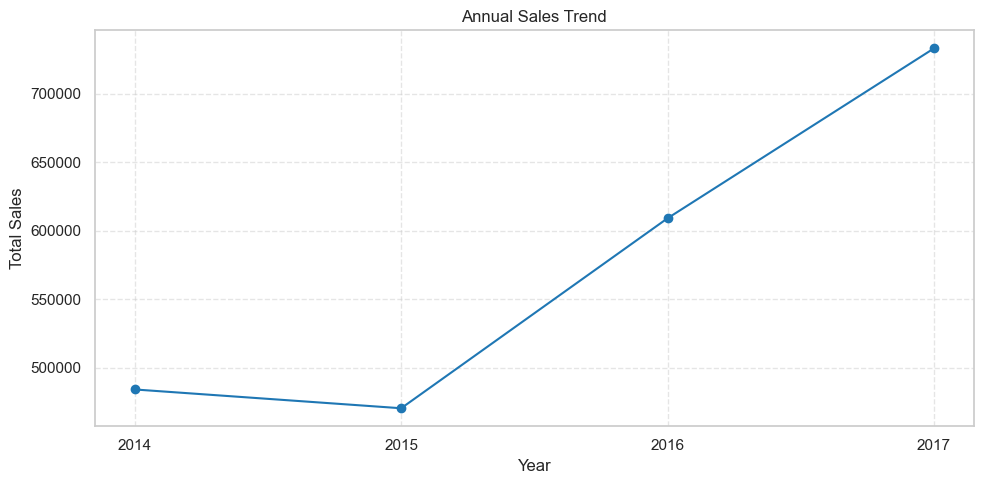

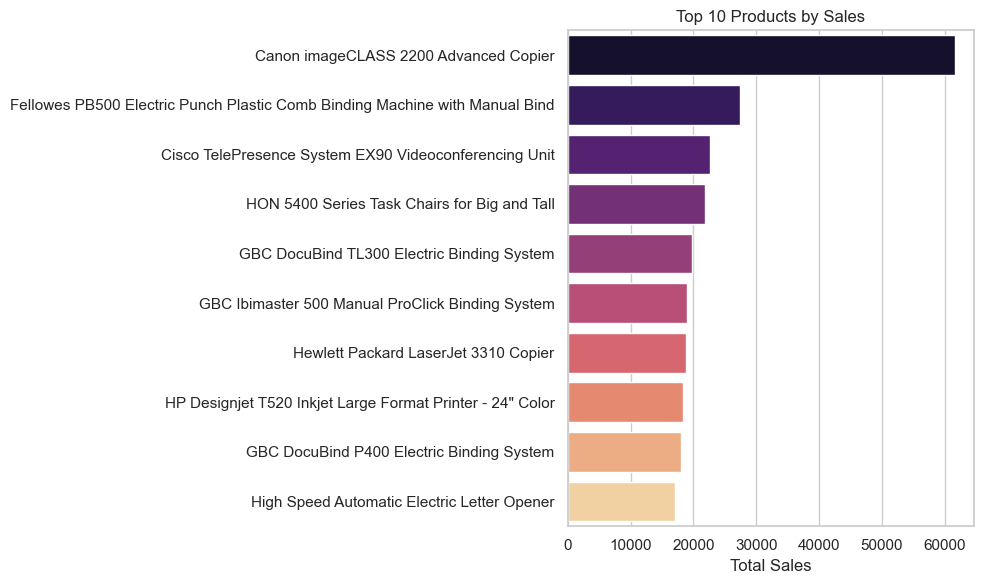

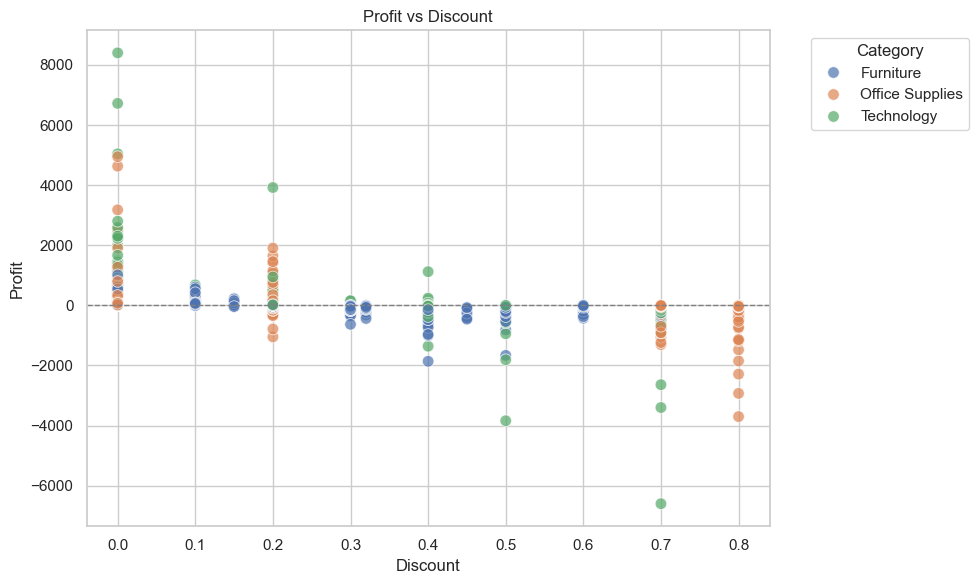


Comparative insights:
- Matplotlib is effective for custom line charts and gives fine-grained control over styling.
- Seaborn makes creating attractive, statistical charts easier with less boilerplate.
- Plotly adds interactivity for maps and complex visualizations where static Matplotlib output is limited.
- In this notebook, Matplotlib is used for trend analysis, Seaborn for category and relationship analysis,
  and Plotly for the interactive geographic distribution view.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.express as px

# If the notebook already defines `url`, use it; otherwise use the local filename.
source = globals().get("url", "US Superstore data.xls")

# Load the dataset
df = pd.read_excel(source)

# Basic exploration
print("Shape:", df.shape)
print(df.dtypes)
print(df.head(3))

# Clean column names
df.columns = df.columns.str.strip()

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Check for missing values
missing = df.isna().sum()
print("Missing values by column:\n", missing[missing > 0])

# Feature engineering
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")
df["Order Delay (days)"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Drop rows with missing critical fields if any
df = df.dropna(subset=["Order Date", "Ship Date", "Sales", "Profit"])

# 1. Sales trend over years with Matplotlib
sns.set_theme(style="whitegrid")
sales_by_year = df.groupby("Year", as_index=False)["Sales"].sum().sort_values("Year")

plt.figure(figsize=(10, 5))
plt.plot(sales_by_year["Year"], sales_by_year["Sales"], marker="o", linestyle="-", color="#1f77b4")
plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(sales_by_year["Year"].astype(int))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Interactive sales distribution map by country with Plotly
sales_by_country = df.groupby("Country", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
fig = px.choropleth(
    sales_by_country,
    locations="Country",
    locationmode="country names",
    color="Sales",
    hover_name="Country",
    title="Sales Distribution by Country",
    color_continuous_scale="Viridis",
)
fig.show()

# 3. Top 10 products by sales with Seaborn
top_products = (
    df.groupby("Product Name", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x="Sales", y="Product Name", palette="magma")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 4. Profit vs Discount scatter plot with Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.7,
    palette="deep",
    edgecolor="w",
    s=70,
)
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Comparative insights
print("\nComparative insights:")
print("- Matplotlib is effective for custom line charts and gives fine-grained control over styling.")
print("- Seaborn makes creating attractive, statistical charts easier with less boilerplate.")
print("- Plotly adds interactivity for maps and complex visualizations where static Matplotlib output is limited.")
print("- In this notebook, Matplotlib is used for trend analysis, Seaborn for category and relationship analysis,")
print("  and Plotly for the interactive geographic distribution view.")